In [99]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import scipy.optimize as opt
import os
import pickle
from library2_utils.color_scheme import cell_line_colors

# set the font size
plt.rcParams.update({'font.size': 7})
# set Helvetica globally
plt.rcParams['font.family'] = 'Helvetica'

cell_lines_measured = ["HEK293T", "HeLa"]
plot_folder = '../plots/21_fiveUTR_analysis/'
os.makedirs(plot_folder, exist_ok=True)

In [57]:
def get_common_index(x, y):
    common_index = x.index.intersection(y.index)
    return x.loc[common_index], y.loc[common_index]

In [40]:
label_rename = {
    "HUH-7": "HUH7",
    "JEG-3": "JEG3",
    "Tera-1": "Tera1",
    "SK-N-SH": "SKNSH",
    "PC-3": "PC3",
}

# get the name of all files in "reference" folder
reference_files = os.listdir("../design_files/")

reference_dfs = {}
for file in reference_files:
    # if it's not a csv file, skip
    if not file.endswith('.csv'):
        continue
    # if it doesn't start with a number, skip
    if not file[0].isdigit():
        continue
    # get the name for the df from the file name
    # it's the file name without the extension
    name = file.split('.')[0]
    reference_dfs[name] = pd.read_csv("../design_files/" + file, index_col=0)

# for each column, rename it according to label_rename if it's in the dictionary
for key, df in reference_dfs.items():
    df.rename(columns=label_rename, inplace=True)
            
reference_dfs = pd.concat(reference_dfs.values())

In [41]:
all_designs = pd.read_csv("../design_files/all_lib2_designs.csv", index_col=0)
upstream = "CTCTTCCTCATCTCCGGGCCTTTCGACCTGCAGCCCTTTCCCTAC"
downstream = "AGACCTCAAAGCTTGGCAATCCGGTACTGTTGGTAAAGCCACCATG"
all_designs['seq'] = upstream + all_designs['seq'] + downstream
all_designs = all_designs['seq'].to_dict()

In [45]:
mirna_columns = [col for col in reference_dfs.columns if col.startswith('miRNA') and not col=="miRNA" and not col=="miRNA_count"]
reference_dfs['mirna_count'] = reference_dfs.apply(lambda row: row[mirna_columns].notna().sum(), axis=1)
reference_dfs['unique_mirnas'] = reference_dfs.apply(
    lambda row: len(set(e for e in row[mirna_columns] if pd.notna(e))),
    axis=1
)
reference_dfs['mut_mirnas'] = reference_dfs.apply(
    lambda row: any(not str(e).startswith("hsa-") for e in row[mirna_columns] if pd.notna(e)),
    axis=1
)
reference_dfs['miRNA_count'] = reference_dfs.apply(lambda row: ["hsa-" in str(row[col]) for col in mirna_columns].count(True), axis=1)

In [46]:
stability_data = pd.read_csv('../measured_data/2_normalized_log10_all/library2_normalized_stability_data.csv', index_col=0)

In [47]:
relevant_columns = [col for col in stability_data.columns if any(cl in col for cl in cell_lines_measured)]
stability_data = stability_data[relevant_columns]
stability_data.columns = [col + "_3UTR" if not col.endswith("5UTR") else col for col in stability_data.columns]

In [48]:
stability_data = np.log10(stability_data)

In [58]:
stability_data_long = pd.melt(
    stability_data.reset_index(),
    id_vars='index',
    var_name='cell_UTR',
    value_name='stability'
)
stability_data_long.rename(columns={'index': 'construct'}, inplace=True)
stability_data_long['cell_type'] = stability_data_long['cell_UTR'].apply(lambda x: x.split('_')[0])
stability_data_long['UTR'] = stability_data_long['cell_UTR'].apply(lambda x: x.split('_')[1])

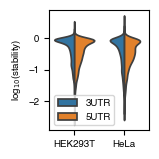

In [59]:

plt.figure(figsize=(1.6,1.6))
sns.violinplot(
    data=stability_data_long,
    x='cell_type',
    y='stability',
    hue='UTR',
    split=True,
    inner=None
)
plt.xlabel("")
plt.ylabel(r"log$_{10}$(stability)")
plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.savefig(os.path.join(plot_folder, '3UTR_vs_5UTR_stability_violinplot.svg'), dpi=400)

In [60]:
# figure out outliers
difference_HEK293T = stability_data['HEK293T_5UTR'] - stability_data['HEK293T_3UTR']
difference_HeLa = stability_data['HeLa_5UTR'] - stability_data['HeLa_3UTR']

low_5utr_HEK293T = difference_HEK293T < -0.5
low_5utr_HEK293T = low_5utr_HEK293T[low_5utr_HEK293T].index.tolist()
low_5utr_HeLa = difference_HeLa < -0.5
low_5utr_HeLa = low_5utr_HeLa[low_5utr_HeLa].index.tolist()
low_5utr_intersection = list(set(low_5utr_HEK293T) & set(low_5utr_HeLa))
low_5utr_union = list(set(low_5utr_HEK293T) | set(low_5utr_HeLa))

In [61]:
all_designs = pd.read_csv("../design_files/all_lib2_designs.csv", index_col=0)

def find_ATG_positions(seq):
    """Get the positions of all ATGs in a sequence"""
    return [i for i in range(len(seq)) if seq[i:i+3] == "ATG"]

def find_distance_to_start(ATG_positions, seq):
    """Find the distance to the start of the CDS"""
    distance_to_start_3p = 43
    seq_length = len(seq)
    dist_to_start = [distance_to_start_3p + seq_length - ATG_pos for ATG_pos in ATG_positions]
    return dist_to_start

# find the position of all ATGs in all_designs
all_designs["ATG_positions"] = all_designs["seq"].apply(find_ATG_positions)
# find the distance to the start of the CDS
all_designs["dist_to_start"] = all_designs.apply(lambda row: find_distance_to_start(row["ATG_positions"], row["seq"]), axis=1)
# get the mod3 value
all_designs["dist_to_start_mod3"] = all_designs["dist_to_start"].apply(lambda x: [pos % 3 for pos in x])
# get the number of ATGs
all_designs["num_ATGs"] = all_designs["ATG_positions"].apply(len)

In [62]:
common_index = stability_data.index.intersection(all_designs.index)
stability_data = stability_data.loc[common_index]
all_designs = all_designs.loc[common_index]
reference_dfs = reference_dfs.loc[common_index]

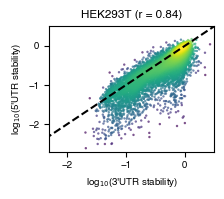

In [63]:
from scipy.stats import gaussian_kde

x = stability_data['HEK293T_3UTR'].dropna()
y = stability_data['HEK293T_5UTR'].dropna()

# calculate density for each point
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# sort points by density so densest are plotted on top
idx = z.argsort()
x, y, z = x.iloc[idx], y.iloc[idx], z[idx]

z_log = np.log10(z + 1e-6)
plt.figure(figsize=(2.4,2))
plt.scatter(x, y, c=z_log, s=3, cmap='viridis', alpha=0.7, edgecolors='none', rasterized=True)
plt.plot([-3,1], [-3,1], 'k--')

plt.xlim(-2.3, 0.5)
plt.ylim(-2.7, 0.5)

plt.xlabel(r"log$_{10}$(3'UTR stability)")
plt.ylabel(r"log$_{10}$(5'UTR stability)")

r = np.corrcoef(x, y)[0, 1]
plt.title(f"HEK293T (r = {r:.2f})")
plt.tight_layout()
plt.savefig(os.path.join(plot_folder, '5UTR_vs_3UTR_stability_density_HEK293T.svg'), dpi=400)

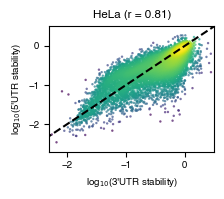

In [64]:
x = stability_data['HeLa_3UTR'].dropna()
y = stability_data['HeLa_5UTR'].dropna()

# calculate density for each point
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# sort points by density so densest are plotted on top
idx = z.argsort()
x, y, z = x.iloc[idx], y.iloc[idx], z[idx]

z_log = np.log10(z + 1e-6)
plt.figure(figsize=(2.4,2))
plt.scatter(x, y, c=z_log, s=3, cmap='viridis', alpha=0.7, edgecolors='none', rasterized=True)
plt.plot([-3,1], [-3,1], 'k--')

plt.xlim(-2.3, 0.5)
plt.ylim(-2.7, 0.5)

plt.xlabel(r"log$_{10}$(3'UTR stability)")
plt.ylabel(r"log$_{10}$(5'UTR stability)")

r = np.corrcoef(x, y)[0, 1]
plt.title(f"HeLa (r = {r:.2f})")
plt.tight_layout()
plt.savefig(os.path.join(plot_folder, '5UTR_vs_3UTR_stability_density_HeLa.svg'), dpi=400)
plt.show()

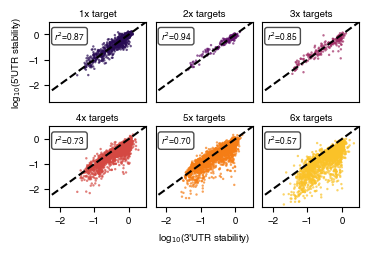

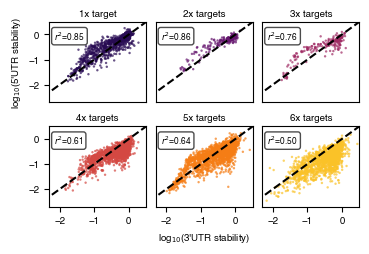

In [132]:
for cell_line in cell_lines_measured:
    x = stability_data.loc[:, f'{cell_line}_3UTR'].dropna()
    y = stability_data.loc[:, f'{cell_line}_5UTR'].dropna()

    colors = sns.color_palette("inferno", n_colors=6)
    z_log = np.log10(z + 1e-6)
    fig, axes = plt.subplots(2,3,figsize=(4,2.4), sharex=True, sharey=True)
    axes = axes.flatten()
    for i, mirna_count in enumerate([1, 2, 3, 4, 5, 6]):
        ax = axes[i]
        x_subset = x[
            (reference_dfs.loc[x.index, 'miRNA_count'] == mirna_count) &
            (reference_dfs.loc[x.index, 'mut_mirnas'] == False)
            ]
        y_subset = y[
            (reference_dfs.loc[x.index, 'miRNA_count'] == mirna_count) &
            (reference_dfs.loc[x.index, 'mut_mirnas'] == False)
            ]
        x,y = get_common_index(x,y)
        ax.scatter(x_subset, y_subset, color=colors[i], s=3, alpha=0.7, edgecolors='none', rasterized=True)
        ax.plot([-3,1], [-3,1], 'k--')
        
        r2 = stats.pearsonr(x_subset, y_subset)[0]**2
        ax.text(0.05, 0.9, f"$r^2$={r2:.2f}", transform=ax.transAxes, fontsize=6, verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='white', alpha=0.7))

        ax.set_xlim(-2.3, 0.5)
        ax.set_ylim(-2.7, 0.5)

        ax.set_xticks([-2, -1, 0])
        ax.set_yticks([-2, -1, 0])

        if i%3 != 0:
            ax.tick_params(axis='y', length=0)
        if i < 3:
            ax.tick_params(axis='x', length=0)
        if i == 4:
            ax.set_xlabel(r"log$_{10}$(3'UTR stability)")
        if i == 0:
            ax.set_ylabel(r"log$_{10}$(5'UTR stability)")
        ax.set_title(f"{mirna_count}x target{'s' if mirna_count > 1 else ''}", fontsize=7, pad=4)
    plt.subplots_adjust(wspace=0.1, hspace=0.3)
    plt.savefig(os.path.join(plot_folder, f'5UTR_vs_3UTR_stability_by_miRNA_count_{cell_line}.svg'), dpi=400)

In [93]:
df_combined = pd.read_csv("../microrna_data/3_output/Alles_Keller_combined_expression_wo_crosstalk_scaled.csv", index_col=0)
df_combined_with_crosstalk = pd.read_csv("../microrna_data/3_output/Alles_Keller_combined_expression_with_crosstalk.csv", index_col=0)

df_combined = df_combined.dropna()
mirna_expression = df_combined
used_mirna_name = "combined_dataset"

with open(f"../outputs/3_fitting/{used_mirna_name}/{used_mirna_name}_popt_wo_crosstalk.pkl", "rb") as f:
    popt = pickle.load(f)
    
from library2_utils.transfer_functions import transfer_function    

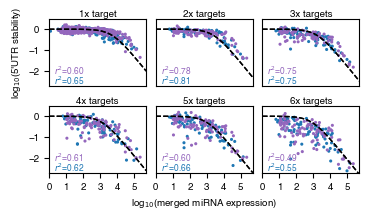

In [134]:
x_range_log = np.linspace(0, 5.7, 100)

fig, axes = plt.subplots(2,3,figsize=(4,2), sharex=True, sharey=True)
axes = axes.flatten()
for i, mirna_count in enumerate([1, 2, 3, 4, 5, 6]):
    ax = axes[i]
    for j, cell_line in enumerate(cell_lines_measured):
        x = df_combined.loc[:, f'{cell_line}'].dropna()
        y = stability_data.loc[:, f'{cell_line}_5UTR'].dropna()
        
        subset = reference_dfs[
            (reference_dfs['miRNA_count'] == mirna_count) &
            (reference_dfs['mut_mirnas'] == False) &
            (reference_dfs['unique_mirnas'] == 1)
            ]
        subset = subset.reset_index().set_index("miRNA1")
        subset = subset[subset['index'].isin(y.index)]
        subset = subset[~subset['index'].str.startswith("4_")]
        subset, x_subset = get_common_index(subset, x)
        
        y_subset = y.loc[subset['index']] 
        x_subset = x_subset.values
        y_subset = y_subset.values
        
        ax.scatter(x_subset, y_subset, color=cell_line_colors[cell_line], s=5, alpha=1, edgecolors='none', rasterized=True)
        ax.plot(
            x_range_log,
            np.log10(transfer_function(mirna_count*10**x_range_log, *popt)),
            color="black", linewidth=1, ls="--"
            )

        prediction = np.log10(transfer_function(
            mirna_count*10**x_subset,
            *popt
        ))

        # calculate the R2 value
        r2 = stats.pearsonr(prediction, y_subset)[0]**2
        
        ax.text(0.05, 0.17+j*0.15,
                f"$r^2$={r2:.2f}",
                transform=ax.transAxes,
                fontsize=6,
                verticalalignment='top',
                color=cell_line_colors[cell_line]
                )

    ax.set_xlim(0, 5.7)
    ax.set_ylim(-2.7, 0.5)

    ax.set_xticks([0, 1, 2, 3, 4, 5])
    ax.set_yticks([-2, -1, 0])
    
    if i%3 != 0:
        ax.tick_params(axis='y', length=0)
    if i < 3:
        ax.tick_params(axis='x', length=0)
    if i == 4:
        ax.set_xlabel(r"log$_{10}$(merged miRNA expression)")
    if i == 0:
        ax.set_ylabel(r"log$_{10}$(5'UTR stability)")
    ax.set_title(f"{mirna_count}x target{'s' if mirna_count > 1 else ''}", fontsize=7, pad=-0.1)
    ax.label_outer()
plt.subplots_adjust(wspace=0.1, hspace=0.3)
plt.savefig(os.path.join(plot_folder, f'5UTR_vs_miRNA_expression_by_miRNA_count.svg'), dpi=400)

In [ ]:
difference_HEK293T = difference_HEK293T.sort_values()
difference_HeLa = difference_HeLa.loc[difference_HEK293T.index]

r = np.corrcoef(difference_HEK293T, difference_HeLa)[0,1]
print(f"Spearman correlation (rho) between HEK293T and HeLa differences: {r:.2f}")

In [153]:
difference_both = pd.DataFrame({
    'HEK293T': difference_HEK293T,
    'HeLa': difference_HeLa
})
difference_both['prefix'] = difference_both.index.str.split('_').str[0]

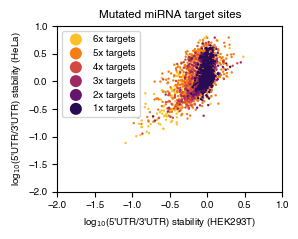

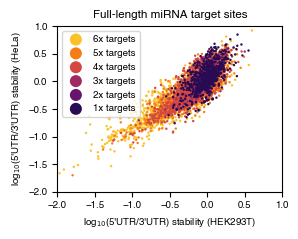

In [ ]:
# colors = sns.color_palette("inferno", n_colors=6)
# for mut_mirnas in [True, False]:
#     plt.figure(figsize=(3,2.4))
#     for mirna_count in np.arange(6,0,-1):
#         designs = reference_dfs[reference_dfs['mirna_count'] == mirna_count]
#         designs = designs[designs['mut_mirnas'] == mut_mirnas]
#         subset = difference_both[difference_both.index.isin(designs.index)]
#         if len(subset) < 10:
#             continue
#         plt.scatter(subset['HEK293T'], subset['HeLa'], s=3, alpha=1, edgecolors='none',
#                     rasterized=True, color=colors[mirna_count-1], label=f"{mirna_count}x targets")
#     plt.legend(loc='upper left', markerscale=5)
#     plt.xlabel(r"log$_{10}$(5'UTR/3'UTR) stability (HEK293T)")
#     plt.ylabel(r"log$_{10}$(5'UTR/3'UTR) stability (HeLa)")
#     plt.title("Mutated miRNA target sites" if mut_mirnas else "Full-length miRNA target sites")
#     plt.xlim(-2,1)
#     plt.ylim(-2,1)
#     plt.tight_layout()
#     plt.savefig(os.path.join(plot_folder, f'5UTR_vs_3UTR_stability_difference_by_miRNA_count_mutmiRNAs_{mut_mirnas}.svg'), dpi=400)

In [154]:
difference_both['rank_HEK293T'] = stats.rankdata(difference_both['HEK293T'])
difference_both['rank_HeLa'] = stats.rankdata(difference_both['HeLa'])

difference_both['mean_rank'] = (difference_both['rank_HEK293T'] + difference_both['rank_HeLa']) / 2
difference_both = difference_both.sort_values('mean_rank')

In [178]:
difference_both[mirna_columns] = reference_dfs.loc[difference_both.index, mirna_columns]

# get only the high confidence microRNAs in mirbase
mirbase = pd.read_csv("../microrna_data/mirbase_extended.csv", index_col=0)
mirbase = mirbase['target'].to_dict()
for mirna_col in mirna_columns:
    difference_both[f"{mirna_col}_seq"] = difference_both[mirna_col].map(mirbase)

In [179]:
mirbase = pd.read_csv("../microrna_data/mirbase_extended.csv", index_col=0)
mirbase.loc['hsa-miR-203a-3p', 'target']

'TAGTGGTCCTAAACATTTCAC'

In [160]:
difference_both = difference_both.copy()
difference_both['full_5utr'] = difference_both.index.map(all_designs['seq'])
difference_both = difference_both.dropna(subset=['full_5utr'])

In [ ]:
#difference_both.to_excel(os.path.join(plot_folder, '5UTR_vs_3UTR_stability_difference_all_data.xlsx'))

In [161]:
# Detect ATG and in-frame stop codons in 5'UTR sequences
def find_uorfs(seq: str):
    """Return ATG positions, stop positions, and in-frame uORF pairs."""
    if not isinstance(seq, str) or len(seq) < 3:
        return [], [], []
    seq = seq.upper()
    atg_positions = [i for i in range(len(seq) - 2) if seq[i:i+3] == "ATG"]
    stop_positions = [i for i in range(len(seq) - 2) if seq[i:i+3] in ["TAA", "TAG", "TGA"]]
    
    uorf_pairs = []
    for start in atg_positions:
        # find the first stop codon downstream and in frame
        for stop in stop_positions:
            if stop > start and (stop - start) % 3 == 0:
                uorf_pairs.append((start, stop))
                break  # stop after the first in-frame stop
    
    return atg_positions, stop_positions, uorf_pairs

difference_both[["AUG_positions", "Stop_positions", "uORF_pairs"]] = (
    difference_both['full_5utr']
    .apply(lambda x: pd.Series(find_uorfs(x)))
)

difference_both["uORF_count"] = difference_both["uORF_pairs"].apply(len)
difference_both["AUG_count"] = difference_both["AUG_positions"].apply(len)
difference_both["Stop_count"] = difference_both["Stop_positions"].apply(len)
difference_both["has_uORF"] = difference_both["uORF_count"] > 0

In [162]:
difference_both['miRNA_count'] = difference_both[mirna_columns].apply(
    lambda row: [pd.notna(row[col]) for col in mirna_columns].count(True),
    axis=1
)

In [163]:
difference_both["has_203a-3p"] = difference_both[mirna_columns].apply(
    lambda x: "hsa-miR-203a-3p" in x.values, axis=1
)
difference_both["has_203a-3p_pos1"] = difference_both['miRNA1'].apply(
    lambda x: x=="hsa-miR-203a-3p"
)

In [164]:
difference_both_subset = difference_both[difference_both['miRNA_count'] == 6]

In [166]:
difference_both_subset

,HEK293T,HeLa,prefix,rank_HEK293T,rank_HeLa,mean_rank,miRNA1,miRNA2,miRNA3,miRNA4,...,AUG_positions,Stop_positions,uORF_pairs,uORF_count,AUG_count,Stop_count,has_uORF,miRNA_count,has_203a-3p,has_203a-3p_pos1
32_miRNA_full_subset_double_target_AND6_30,-1.971501,-1.664395,32,1.0,2.0,1.5,hsa-miR-203a-3p,hsa-miR-203a-3p,hsa-miR-203a-3p,hsa-miR-1180-5p,...,[],"[17, 24, 33, 51, 60, 78, 87, 132, 141, 172]",[],0,0,10,False,6,True,True
10_miRNA_full_repeat_x6_79,-1.913332,-1.598173,10,2.0,3.0,2.5,hsa-miR-203a-3p,hsa-miR-203a-3p,hsa-miR-203a-3p,hsa-miR-203a-3p,...,[],"[17, 24, 33, 51, 60, 78, 87, 105, 114, 132, 14...",[],0,0,13,False,6,True,True
32_miRNA_full_subset_double_target_AND6_29,-1.781420,-1.548736,32,4.0,4.0,4.0,hsa-miR-203a-3p,hsa-miR-203a-3p,hsa-miR-203a-3p,hsa-miR-452-3p,...,[120],"[17, 24, 33, 51, 60, 78, 87, 121, 132, 141, 172]","[(120, 132)]",1,1,11,True,6,True,True
35_miRNA_full_all_range_target_log_AND6_91,-1.725767,-1.514914,35,5.0,6.0,5.5,hsa-miR-302a-5p,hsa-miR-107,hsa-miR-183-5p,hsa-miR-203a-3p,...,"[63, 141]","[17, 40, 51, 79, 105, 114, 129, 142, 159, 168]","[(63, 105), (141, 159)]",2,2,10,True,6,True,False
15_miRNA_full_combination_probe_x6_10,-1.452795,-1.401161,15,13.0,7.0,10.0,hsa-miR-140-5p,hsa-miR-135b-5p,hsa-miR-135b-5p,hsa-miR-183-5p,...,"[57, 84, 144]","[17, 29, 34, 43, 52, 58, 68, 79, 85, 95, 106, ...",[],0,3,13,False,6,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32_miRNA_full_subset_random_target_log_AND6_51,0.308421,0.564079,32,9956.0,9883.0,9919.5,hsa-miR-199a-5p,hsa-miR-26a-5p,hsa-miR-26a-5p,hsa-miR-122-3p,...,"[117, 171]","[17, 29, 34, 68, 95, 107, 112, 115, 174, 177]","[(117, 174), (171, 174)]",2,2,10,True,6,False,False
21_miRNA_mut_combination_probe_x6_88,0.296008,0.605299,21,9946.0,9936.0,9941.0,5.6_miRNA_miR-21-5p_smut4_swob_omut16_owob,5.17_miRNA_miR-24-3p_smut_swob_omut_owob9.13.17,5.15_miRNA_miR-31-5p_smut_swob_omut9.11_owob21,5.14_miRNA_miR-31-5p_smut_swob_omut17.19.21_owob,...,[81],"[17, 35, 38, 43, 60, 65, 133, 152, 170, 173]",[],0,1,10,False,6,False,False
32_miRNA_full_subset_single_active_AND6_4,0.251974,0.815262,32,9902.0,9998.0,9950.0,hsa-miR-335-5p,hsa-miR-23a-3p,hsa-miR-5187-5p,hsa-miR-21-3p,...,"[63, 144]","[17, 42, 66, 129, 134, 139, 142]","[(63, 66)]",1,2,7,True,6,False,False
35_miRNA_full_all_random_target_log_AND6_60,0.315270,0.735931,35,9960.0,9987.0,9973.5,hsa-miR-203a-3p,hsa-miR-24-3p,hsa-miR-6758-5p,hsa-miR-3187-3p,...,"[117, 144]","[17, 24, 33, 60, 65, 129]","[(117, 129)]",1,2,6,True,6,True,True


In [167]:
difference_both_subset['mean_293T_HeLa'] = difference_both_subset[['HEK293T', 'HeLa']].mean(axis=1)

C:\Users\loesi\AppData\Local\Temp\ipykernel_11896\4164119528.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  difference_both_subset['mean_293T_HeLa'] = difference_both_subset[['HEK293T', 'HeLa']].mean(axis=1)


In [168]:
difference_both_subset['mean_293T_HeLa']

32_miRNA_full_subset_double_target_AND6_30       -1.817948
10_miRNA_full_repeat_x6_79                       -1.755753
32_miRNA_full_subset_double_target_AND6_29       -1.665078
35_miRNA_full_all_range_target_log_AND6_91       -1.620340
15_miRNA_full_combination_probe_x6_10            -1.426978
                                                    ...   
32_miRNA_full_subset_random_target_log_AND6_51    0.436250
21_miRNA_mut_combination_probe_x6_88              0.450653
32_miRNA_full_subset_single_active_AND6_4         0.533618
35_miRNA_full_all_random_target_log_AND6_60       0.525600
35_miRNA_full_all_range_target_log_AND6_54        0.760129
Name: mean_293T_HeLa, Length: 1680, dtype: float64

C:\Users\loesi\AppData\Local\Temp\ipykernel_11896\481259646.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.boxplot(
C:\Users\loesi\AppData\Local\Temp\ipykernel_11896\481259646.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


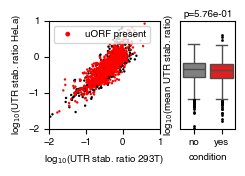

C:\Users\loesi\AppData\Local\Temp\ipykernel_11896\481259646.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.boxplot(
C:\Users\loesi\AppData\Local\Temp\ipykernel_11896\481259646.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


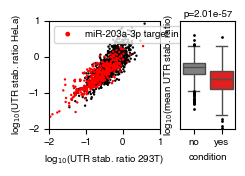

C:\Users\loesi\AppData\Local\Temp\ipykernel_11896\481259646.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.boxplot(
C:\Users\loesi\AppData\Local\Temp\ipykernel_11896\481259646.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


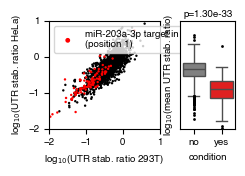

In [174]:
from scipy.stats import mannwhitneyu

def plot_impact_of_variable(df, column_name, plot_significance=True, savepath=None, label=None):
    # --- Figure with two subplots of equal height ---
    fig, (ax0, ax1) = plt.subplots(
        1, 2, figsize=(2.4, 1.4), gridspec_kw=dict(wspace=0.25), width_ratios=[2,1]
    )

    to_test = df[df[column_name]]
    other   = df[~df[column_name]]

    # --- Left: scatter ---
    ax0.scatter(other['HEK293T'], other['HeLa'], s=3, alpha=1, edgecolors='none',
                rasterized=True, color="black")
    ax0.scatter(to_test['HEK293T'], to_test['HeLa'], s=3, alpha=1, edgecolors='none',
                rasterized=True, color="red", label=column_name if label is None else label)

    ax0.legend(loc='upper left', markerscale=2)
    ax0.set_xlabel(r"log$_{10}$(UTR stab. ratio 293T)")
    ax0.set_ylabel(r"log$_{10}$(UTR stab. ratio HeLa)")
    ax0.set_xlim(-2, 1)
    ax0.set_ylim(-2, 1)

    # --- Right: boxplot with stat test + significance bar ---
    order = [False, True]  # ensure consistent left/right positions
    bp = sns.boxplot(
        data=df,
        x=column_name,
        y="HEK293T",
        order=order,
        palette={"False": "gray", "True": "red"},
        flierprops={'marker': 'o', 'markersize': 2, 'markeredgecolor': 'none', 'markerfacecolor': 'black'},
        showfliers=True,
        ax=ax1
    )

    ax1.set_xlabel("condition")
    ax1.set_ylabel(r"log$_{10}$(mean UTR stab. ratio)")
    ax1.set_xticks([0, 1], ["no", "yes"])
    ax1.set_ylim(-2, 1)
    ax1.set_yticks([])

    if plot_significance:
        # Mann–Whitney U test (nonparametric; robust to non-normality)
        grp_no  = df.loc[~df[column_name], "mean_293T_HeLa"].dropna()
        grp_yes = df.loc[ df[column_name], "mean_293T_HeLa"].dropna()
        u_stat, p_val = mannwhitneyu(grp_no, grp_yes, alternative="two-sided")

        # Add significance bar between the two boxes
        y_max = max(np.nanmax(grp_no), np.nanmax(grp_yes))
        y_min = min(np.nanmin(grp_no), np.nanmin(grp_yes))
        h = 0.06 * (y_max - y_min if y_max > y_min else 1.0)  # bar height
        y = y_max + h * 0.8
        x0, x1 = 0, 1

        #ax1.plot([x0, x0, x1, x1], [y, y+h, y+h, y], lw=1, c='k')
        ax1.text((x0 + x1) / 2, y + h * 1.1, f"p={p_val:.2e}",
                ha='center', va='bottom')

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=400)
    plt.show()
    
plot_impact_of_variable(difference_both_subset, "has_uORF", plot_significance=True,
                        label = "uORF present",
                        savepath=os.path.join(plot_folder, '5UTR_vs_3UTR_stability_difference_uORF_impact.svg'))
plot_impact_of_variable(difference_both_subset, "has_203a-3p", plot_significance=True,
                        label = "miR-203a-3p target in 5'UTR",
                        savepath=os.path.join(plot_folder, '5UTR_vs_3UTR_stability_difference_203a-3p_impact.svg'))
plot_impact_of_variable(difference_both_subset, "has_203a-3p_pos1", plot_significance=True,
                        label = "miR-203a-3p target in 5'UTR\n(position 1)",
                        savepath=os.path.join(plot_folder, '5UTR_vs_3UTR_stability_difference_203a-3p_pos1_impact.svg'))

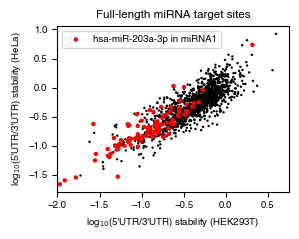

In [112]:
plt.figure(figsize=(3,2.4))

designs = reference_dfs[reference_dfs['mirna_count'] == 6]
designs = designs[designs['mut_mirnas'] == False]
subset = difference_both[difference_both.index.isin(designs.index)]

contains_203a = subset[subset["miRNA1"] == "hsa-miR-203a-3p"]
other = subset[subset["miRNA1"] != "hsa-miR-203a-3p"]

plt.scatter(other['HEK293T'], other['HeLa'], s=3, alpha=1, edgecolors='none',
            rasterized=True, color="black")
plt.scatter(contains_203a['HEK293T'], contains_203a['HeLa'], s=10, alpha=1, edgecolors='none',
            rasterized=True, color="red", label="hsa-miR-203a-3p in miRNA1")

plt.legend(loc='upper left', markerscale=1)
plt.xlabel(r"log$_{10}$(5'UTR/3'UTR) stability (HEK293T)")
plt.ylabel(r"log$_{10}$(5'UTR/3'UTR) stability (HeLa)")
plt.title("Mutatated miRNA target sites" if mut_mirnas else "Full-length miRNA target sites")
plt.xlim(-2,0.75)
plt.xlim(-2,0.75)
plt.tight_layout()
plt.show()
#plt.savefig(os.path.join(plot_folder, f'5UTR_vs_3UTR_stability_difference_by_miRNA_count_mutmiRNAs_{mut_mirnas}.svg'), dpi=400)

In [97]:
value_counts_by_column = {}
for col in mirna_columns:
    value_counts_by_column[col] = top20[col].value_counts()

In [177]:
mirbase['hsa-miR-203a-3p']

'TAGTGGTCCTAAACATTTCAC'

In [175]:
mirbase.loc['hsa-miR-203a-3p', 'target']

AttributeError: 'dict' object has no attribute 'loc'